# 6b. Modelling with MultiStep

This notebook implements **models** for revenue forecasting at the Business Subsegment level, organized in two main parts:


- **6.2 Machine Learning Models** - ML models leveraging the full set of engineered features from Feature Selection.

---

**Target**: Revenue cons. (anon) - Orders used as leading indicator (not a target).  
**Granularity**: One model per TGL Business Subsegment (134 series).  
**Validation**: Train on periods 1–36, validate on 37–42 (6-period horizon).  
**Test**: Periods 43–48 (all targets NaN).  
**Metrics**: RMSE, MAE, wMAPE (weighted MAPE - robust to near-zero revenue subsegments), R² (coefficient of determination).  


**6.2 ML Models**: Defined lower in this notebook.

> **Note**: TS models (6.1) operate on the raw Revenue/Orders series per subsegment. Categorical columns serve as **grouping keys**. ML models (6.2) leverage the 100 engineered features from Feature Selection.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────
# REQUIRED PACKAGE INSTALLS
# Run this cell once to ensure all dependencies are available in your kernel.
# Safe to re-run - pip will skip already-installed packages.
# ─────────────────────────────────────────────────────────────────────────
import subprocess, sys

packages = [
    'lightgbm',       # Gradient boosting (LightGBM)
    'xgboost',        # Gradient boosting (XGBoost)
    'catboost',       # Gradient boosting (CatBoost) - also fixes clone() issue
    'pmdarima',       # SARIMA (auto_arima)
    'prophet',        # Facebook Prophet
    'statsmodels',    # VAR, ETS / Holt-Winters
    'scikit-learn',   # Ridge, Lasso, RandomForest, etc.
    'pandas',
    'numpy',
    'matplotlib',
    'seaborn',
    'pyarrow',        # Parquet file reading
]

result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade'] + packages,
    capture_output=True, text=True
)
if result.returncode == 0:
    print('All packages installed / up-to-date')
else:
    print('Some packages failed to install:')
    print(result.stderr[-2000:])

# Direct Multi-Step vs Recursive Forecasting

> NOTE!  
> **Understanding the Forecasting Approach in this Notebook**
>
> While `6)Modelling.ipynb` evaluated machine learning models using a **Recursive Forecasting** engine (feeding step $t$ predictions iteratively to compute lag features for step $t+1$), this notebook utilizes a **Direct Multi-Step Forecasting** approach.
> 
> **Direct Multi-Step:**
> - We explicitly construct target columns shifted by the horizon step, i.e., $y_{t+h}$.
> - Separate models (or a separate model state) are trained for *each* forecasting horizon $h \in \{1, 2, 3, 4, 5, 6\}$.
> - This cleanly avoids data leakage by ensuring the model predicting $y_{t+h}$ only ever sees features derived from actual data available at time $t$.
> - We implement this at **all levels** of the hierarchy (Subsegment, Segment, and Business Unit) before reconciling the base forecasts using MinT.

## 6.0 Imports & Data Loading

In [2]:
import os, sys
import time

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb
import xgboost as xgb


# Register DLL directories BEFORE any heavy imports (fixes WinError 127 with torch on Windows)
if os.name == 'nt':
    _lib_bin = os.path.join(sys.prefix, 'Library', 'bin')
    if os.path.isdir(_lib_bin):
        os.environ['PATH'] = _lib_bin + os.pathsep + os.environ.get('PATH', '')
        if hasattr(os, 'add_dll_directory'):
            try: os.add_dll_directory(_lib_bin)
            except OSError: pass
    import importlib.util as _ilu
    _spec = _ilu.find_spec('torch')
    if _spec and _spec.origin:
        for _subdir in ('lib', 'bin'):
            _d = os.path.join(os.path.dirname(_spec.origin), _subdir)
            if os.path.isdir(_d):
                os.environ['PATH'] = _d + os.pathsep + os.environ.get('PATH', '')
                if hasattr(os, 'add_dll_directory'):
                    try: os.add_dll_directory(_d)
                    except OSError: pass

sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

# Sklearn - preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder

# Baseline models
from src.code.baseline_models import *

%load_ext autoreload
%autoreload 2


print('All imports successful.')

All imports successful.


In [3]:
data_dir = '../data/features'

train_full = pd.read_parquet(os.path.join(data_dir, 'training_subsegment_fs.parquet'))
test_df    = pd.read_parquet(os.path.join(data_dir, 'validation_subsegment_fs.parquet'))

TARGET     = 'Revenue cons. (anon)'
ORDERS_COL = 'Orders cons. (anon)'
PERIOD_COL = 'Anon Period'
SUBSEG_COL = 'TGL Business Subsegment'
ID_COLS    = ['Anon Period', 'TGL Business Unit', 'TGL Business Segment', 'TGL Business Subsegment']

print(f'Training:   {train_full.shape}  |  Periods: {train_full[PERIOD_COL].min()}–{train_full[PERIOD_COL].max()}')
print(f'Test:       {test_df.shape}  |  Periods: {test_df[PERIOD_COL].min()}–{test_df[PERIOD_COL].max()}')
print(f'Unique subsegments: {train_full[SUBSEG_COL].nunique()}')

Training:   (4237, 106)  |  Periods: 1–42
Test:       (715, 106)  |  Periods: 43–48
Unique subsegments: 134


## 6.0.1 Internal Validation Split

The test set (periods 43–48) has all targets as NaN. We create an internal temporal split from training data:
- **Train**: periods 1–36
- **Validation**: periods 37–42 (mimics the 6-period test horizon)

In [7]:
VAL_CUTOFF = 36
HORIZON    = 6

train_df = train_full[train_full[PERIOD_COL] <= VAL_CUTOFF].copy()
val_df   = train_full[train_full[PERIOD_COL] > VAL_CUTOFF].copy()

subsegments = get_valid_subsegments(train_df, TARGET)

# Series length diagnostics
lengths = [len(get_subsegment_series(train_df, s, PERIOD_COL, TARGET).dropna()) for s in subsegments]

print(f'Internal train: {train_df.shape} - periods {train_df[PERIOD_COL].min()}–{train_df[PERIOD_COL].max()}')
print(f'Internal val:   {val_df.shape} - periods {val_df[PERIOD_COL].min()}–{val_df[PERIOD_COL].max()}')
print(f'\nSubsegments with revenue data: {len(subsegments)}')
print(f'Series lengths - min: {min(lengths)}, median: {np.median(lengths):.0f}, max: {max(lengths)}')
print(f'Series with ≥ 24 points (seasonal SARIMA): {sum(l >= 24 for l in lengths)}')
print(f'Series with < 12 points: {sum(l < 12 for l in lengths)}')

Internal train: (3524, 106) - periods 1–36
Internal val:   (713, 106) - periods 37–42

Subsegments with revenue data: 117
Series lengths - min: 2, median: 36, max: 36
Series with ≥ 24 points (seasonal SARIMA): 93
Series with < 12 points: 12


---

## 6.2 Machine Learning Models

This section benchmarks ML models for revenue forecasting using **direct multi-step prediction** to avoid data leakage and error propagation.

---
### 6.2.0 Imports & Configuration

In [8]:
from src.code.functions_models_v2 import * 

# Column aliases (from defaults in functions_models.py)
TARGET     = DEFAULT_TARGET
ORDERS_COL = DEFAULT_ORDERS_COL
PERIOD_COL = DEFAULT_PERIOD_COL
SUBSEG_COL = DEFAULT_SUBSEG_COL
SEG_COL    = DEFAULT_SEG_COL
BU_COL     = DEFAULT_BU_COL

VAL_CUTOFF = 36   # Train: periods 1-36, Validation: periods 37-42
HORIZON    = 6    # 6-period forecast horizon (matches test set)

print(f'Train:      periods 1-{VAL_CUTOFF}')
print(f'Validation: periods {VAL_CUTOFF+1}-{VAL_CUTOFF+HORIZON}')
print(f'Test:       periods 43-48 (targets unknown)')

Train:      periods 1-36
Validation: periods 37-42
Test:       periods 43-48 (targets unknown)


### 6.2.1. Direct Multi-Step Forecasting

In [9]:
# ─────────────────────────────────────────────────────────────────────────
# DIRECT MULTI-STEP FORECASTING (MULTIPLE MODELS, SUBSEGMENT-LEVEL)
# ─────────────────────────────────────────────────────────────────────────
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# 1. Define the features to use
FEATURES = [col for col in train_full.columns if col not in ID_COLS + [TARGET, ORDERS_COL]]

# 2. Define the models to be evaluated
# Note: We wrap Ridge and RandomForest in a Pipeline with SimpleImputer to handle potential NaNs
models_dict = {
    'Ridge (Linear)': Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')), 
        ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    ]),
    'XGBoost': xgb.XGBRegressor(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMRegressor(n_estimators=150, max_depth=5, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1),
    'CatBoost': cb.CatBoostRegressor(iterations=150, depth=5, learning_rate=0.05, random_state=42, verbose=0)
}

trained_models = {name: {} for name in models_dict.keys()}
val_predictions_list = []

print("=== Starting Direct Multi-Step Training for Multiple Models ===")

for step in range(1, HORIZON + 1):
    print(f"\n--- Preparing Data for Step {step} (Horizon: t+{step}) ---")
    
    # Copy the full dataset and sort it
    df_step = train_full.copy()
    df_step = df_step.sort_values(by=[SUBSEG_COL, PERIOD_COL])
    
    # Shift the target backwards
    target_step_col = f'{TARGET}_lead_{step}'
    df_step[target_step_col] = df_step.groupby(SUBSEG_COL)[TARGET].shift(-step)
    
    # Fix infinites
    df_step[target_step_col] = df_step[target_step_col].replace([np.inf, -np.inf], np.nan)
    
    # Define Train and Validation sets AND DROP NaNs
    train_step_df = df_step[df_step[PERIOD_COL] <= (VAL_CUTOFF - step)].copy()
    train_step_df = train_step_df.dropna(subset=[target_step_col])
    
    val_step_df = df_step[df_step[PERIOD_COL] == VAL_CUTOFF].copy()
    val_step_df = val_step_df.dropna(subset=[target_step_col])
    
    X_train = train_step_df[FEATURES]
    y_train = train_step_df[target_step_col]
    
    X_val = val_step_df[FEATURES]
    y_val = val_step_df[target_step_col]
    
    # Train each model for this step
    for model_name, model_instance in models_dict.items():
        
        # Clone ensures we start with a fresh, untrained model each time
        model = clone(model_instance)
        
        # Fit the model
        model.fit(X_train, y_train)
        
        # Store the trained model
        trained_models[model_name][step] = model
        
        # Generate predictions
        preds = model.predict(X_val)
        
        # Store results for this specific model and step
        temp_val_df = val_step_df[[BU_COL, SEG_COL, SUBSEG_COL, PERIOD_COL]].copy()
        temp_val_df['Actual'] = y_val
        temp_val_df['Prediction'] = preds
        temp_val_df['Forecast_Period'] = temp_val_df[PERIOD_COL] + step 
        temp_val_df['Model'] = model_name
        
        val_predictions_list.append(temp_val_df)
        
    print(f"All models trained for t+{step}. (Train: {len(X_train)} | Val: {len(X_val)} samples)")

# Combine all predictions
all_val_preds = pd.concat(val_predictions_list, ignore_index=True)
print("\n=== All Models Trained Successfully! ===")

=== Starting Direct Multi-Step Training for Multiple Models ===

--- Preparing Data for Step 1 (Horizon: t+1) ---
All models trained for t+1. (Train: 3410 | Val: 106 samples)

--- Preparing Data for Step 2 (Horizon: t+2) ---
All models trained for t+2. (Train: 3296 | Val: 105 samples)

--- Preparing Data for Step 3 (Horizon: t+3) ---
All models trained for t+3. (Train: 3180 | Val: 105 samples)

--- Preparing Data for Step 4 (Horizon: t+4) ---
All models trained for t+4. (Train: 3068 | Val: 105 samples)

--- Preparing Data for Step 5 (Horizon: t+5) ---
All models trained for t+5. (Train: 2960 | Val: 104 samples)

--- Preparing Data for Step 6 (Horizon: t+6) ---
All models trained for t+6. (Train: 2851 | Val: 102 samples)

=== All Models Trained Successfully! ===


### 6.2.2. Evaluate Multi-Step Models

In [10]:
# ─────────────────────────────────────────────────────────────────────────
# EVALUATE MULTI-STEP ML MODELS
# ─────────────────────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

results = []

# Evaluate each model independently
for model_name, group in all_val_preds.groupby('Model'):
    
    # Drop rows where 'Actual' might be NaN
    eval_df = group.dropna(subset=['Actual'])
    
    if len(eval_df) == 0:
        continue
        
    rmse = np.sqrt(mean_squared_error(eval_df['Actual'], eval_df['Prediction']))
    mae = mean_absolute_error(eval_df['Actual'], eval_df['Prediction'])
    r2 = r2_score(eval_df['Actual'], eval_df['Prediction'])
    
    # Calculate wMAPE
    sum_errors = np.sum(np.abs(eval_df['Actual'] - eval_df['Prediction']))
    sum_actuals = np.sum(np.abs(eval_df['Actual']))
    wmape = (sum_errors / sum_actuals) * 100 if sum_actuals != 0 else np.nan
    
    results.append({
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'wMAPE (%)': wmape,
        'R²': r2
    })

# Convert to DataFrame and sort by wMAPE
results_df = pd.DataFrame(results).sort_values(by='wMAPE (%)').reset_index(drop=True)

# Format the numerical columns for better readability
format_dict = {
    'RMSE': '{:,.0f}',
    'MAE': '{:,.0f}',
    'wMAPE (%)': '{:.2f}%',
    'R²': '{:.4f}'
}

print('========================================================================')
print('DIRECT MULTI-STEP ML MODELS — Validation Metrics (Periods 37-42)')
print('========================================================================')

# Display formatted table
display(results_df.style.format(format_dict).hide(axis='index'))

DIRECT MULTI-STEP ML MODELS — Validation Metrics (Periods 37-42)


Model,RMSE,MAE,wMAPE (%),R²
XGBoost,"11,327,380","5,175,391",13.38%,0.9724
LightGBM,"12,101,632","5,254,137",13.58%,0.9685
CatBoost,"10,270,056","5,446,644",14.08%,0.9773
RandomForest,"13,625,487","5,983,083",15.47%,0.9601
Ridge (Linear),"11,395,822","6,944,689",17.95%,0.9721


### 6.2.3 Segment-Level Benchmarking

In [11]:
# ─────────────────────────────────────────────────────────────────────────
# SEGMENT-LEVEL BENCHMARKING (Direct Multi-Step Forecast)
# ─────────────────────────────────────────────────────────────────────────

# Build and clean segment-level data
seg_df = build_segment_level_data(train_full)

# Remove phantom series (BU x Segment combos with zero revenue)
real_mask = seg_df.groupby([BU_COL, SEG_COL])[TARGET].transform('sum') > 0
seg_df = seg_df[real_mask].copy()
sparsity_seg = seg_df.groupby([BU_COL, SEG_COL])[TARGET].transform(lambda x: (x > 0).mean())
seg_df = seg_df[sparsity_seg > 0.30].copy()

print(f'Clean segment dataset: {seg_df.shape}')
print(f'Real series: {seg_df.groupby([BU_COL, SEG_COL]).ngroups}')

# Prepare segment-level train/val split
X_tr_seg, y_tr_seg, X_va_seg, y_va_seg, feat_seg, cat_seg = prepare_segment_data(
    seg_df=seg_df,
    val_cutoff=VAL_CUTOFF
)

print(f'Segment train: {X_tr_seg.shape}, val: {X_va_seg.shape}')
feat_seg = [col for col in feat_seg if col not in ID_COLS]
print(f'Features: {len(feat_seg)}')

# --- Benchmarking ---
print("\n=== Starting Direct Multi-Step Training for Multiple Models at SEGMENT Level ===")

trained_models_seg = {name: {} for name in models_dict.keys()}
val_predictions_seg_list = []

for step in range(1, HORIZON + 1):
    print(f"\n--- Preparing Segment Data for Step {step} (Horizon: t+{step}) ---")
    
    # Copy and sort
    df_step = seg_df.copy()
    df_step = df_step.sort_values(by=[BU_COL, SEG_COL, PERIOD_COL])
    
    # Shift the target backwards natively grouped by Segment and BU
    target_step_col = f'{TARGET}_lead_{step}'
    df_step[target_step_col] = df_step.groupby([BU_COL, SEG_COL])[TARGET].shift(-step)
    
    # Fix infinites
    df_step[target_step_col] = df_step[target_step_col].replace([np.inf, -np.inf], np.nan)
    
    # Train/Val Split
    train_step_df = df_step[df_step[PERIOD_COL] <= (VAL_CUTOFF - step)].copy()
    train_step_df = train_step_df.dropna(subset=[target_step_col])
    
    val_step_df = df_step[df_step[PERIOD_COL] == VAL_CUTOFF].copy()
    val_step_df = val_step_df.dropna(subset=[target_step_col])
    
    X_train = train_step_df[feat_seg]
    y_train = train_step_df[target_step_col]
    
    X_val = val_step_df[feat_seg]
    y_val = val_step_df[target_step_col]
    
    # Train each model
    for model_name, model_instance in models_dict.items():
        model = clone(model_instance)
        
        # Fit model
        model.fit(X_train, y_train)
        trained_models_seg[model_name][step] = model
        
        # Predict
        preds = model.predict(X_val)
        
        temp_val_df = val_step_df[[BU_COL, SEG_COL, PERIOD_COL]].copy()
        temp_val_df['Actual'] = y_val
        temp_val_df['Prediction'] = preds
        temp_val_df['Forecast_Period'] = temp_val_df[PERIOD_COL] + step 
        temp_val_df['Model'] = model_name
        
        val_predictions_seg_list.append(temp_val_df)
        
    print(f"All Segment models trained for t+{step}. (Train: {len(X_train)} | Val: {len(X_val)})")

all_val_preds_seg = pd.concat(val_predictions_seg_list, ignore_index=True)

# Evaluate Segment Models
results_seg = []
for model_name, group in all_val_preds_seg.groupby('Model'):
    eval_df = group.dropna(subset=['Actual'])
    if len(eval_df) == 0: continue
        
    rmse = np.sqrt(mean_squared_error(eval_df['Actual'], eval_df['Prediction']))
    mae = mean_absolute_error(eval_df['Actual'], eval_df['Prediction'])
    r2 = r2_score(eval_df['Actual'], eval_df['Prediction'])
    
    sum_errors = np.sum(np.abs(eval_df['Actual'] - eval_df['Prediction']))
    sum_actuals = np.sum(np.abs(eval_df['Actual']))
    wmape = (sum_errors / sum_actuals) * 100 if sum_actuals != 0 else np.nan
    
    results_seg.append({
        'Model': model_name, 'Level': 'Segment',
        'RMSE': rmse, 'MAE': mae, 'wMAPE (%)': wmape, 'R²': r2
    })

results_seg_df = pd.DataFrame(results_seg).sort_values(by='wMAPE (%)').reset_index(drop=True)
display(results_seg_df.style.format(format_dict).hide(axis='index'))

Segment-level dataset: (4032, 30)
Clean segment dataset: (672, 30)
Real series: 16
Segment train: (576, 26), val: (96, 26)
Features: 24

=== Starting Direct Multi-Step Training for Multiple Models at SEGMENT Level ===

--- Preparing Segment Data for Step 1 (Horizon: t+1) ---
All Segment models trained for t+1. (Train: 560 | Val: 16)

--- Preparing Segment Data for Step 2 (Horizon: t+2) ---
All Segment models trained for t+2. (Train: 544 | Val: 16)

--- Preparing Segment Data for Step 3 (Horizon: t+3) ---
All Segment models trained for t+3. (Train: 528 | Val: 16)

--- Preparing Segment Data for Step 4 (Horizon: t+4) ---
All Segment models trained for t+4. (Train: 512 | Val: 16)

--- Preparing Segment Data for Step 5 (Horizon: t+5) ---
All Segment models trained for t+5. (Train: 496 | Val: 16)

--- Preparing Segment Data for Step 6 (Horizon: t+6) ---
All Segment models trained for t+6. (Train: 480 | Val: 16)


Model,Level,RMSE,MAE,wMAPE (%),R²
LightGBM,Segment,"49,838,032","24,154,514",9.54%,0.9775
XGBoost,Segment,"49,490,236","24,165,045",9.54%,0.9778
RandomForest,Segment,"55,322,294","27,585,774",10.89%,0.9723
CatBoost,Segment,"56,108,305","32,878,876",12.98%,0.9715
Ridge (Linear),Segment,"51,675,486","34,826,621",13.75%,0.9758


### 6.2.4 BU-Level Benchmarking

In [12]:
# ─────────────────────────────────────────────────────────────────────────
# BU-LEVEL BENCHMARKING (Direct Multi-Step Forecast)
# ─────────────────────────────────────────────────────────────────────────

# Build and clean BU-level data
bu_df = build_bu_level_data(train_full)

# Remove phantom series (BUs with zero revenue)
real_mask = bu_df.groupby([BU_COL])[TARGET].transform('sum') > 0
bu_df = bu_df[real_mask].copy()
sparsity_bu = bu_df.groupby([BU_COL])[TARGET].transform(lambda x: (x > 0).mean())
bu_df = bu_df[sparsity_bu > 0.30].copy()

print(f'Clean BU dataset: {bu_df.shape}')
print(f'Real series: {bu_df.groupby([BU_COL]).ngroups}')

# Prepare BU-level train/val split
X_tr_bu, y_tr_bu, X_va_bu, y_va_bu, feat_bu, cat_bu = prepare_bu_data(
    bu_df=bu_df,
    val_cutoff=VAL_CUTOFF
)

print(f'BU train: {X_tr_bu.shape}, val: {X_va_bu.shape}')
feat_bu = [col for col in feat_bu if col not in ID_COLS]
print(f'Features: {len(feat_bu)}')

# --- Benchmarking ---
print("\n=== Starting Direct Multi-Step Training for Multiple Models at BU Level ===")

trained_models_bu = {name: {} for name in models_dict.keys()}
val_predictions_bu_list = []

for step in range(1, HORIZON + 1):
    print(f"\n--- Preparing BU Data for Step {step} (Horizon: t+{step}) ---")
    
    # Copy and sort
    df_step = bu_df.copy()
    df_step = df_step.sort_values(by=[BU_COL, PERIOD_COL])
    
    # Shift the target backwards natively grouped by BU
    target_step_col = f'{TARGET}_lead_{step}'
    df_step[target_step_col] = df_step.groupby([BU_COL])[TARGET].shift(-step)
    
    # Fix infinites
    df_step[target_step_col] = df_step[target_step_col].replace([np.inf, -np.inf], np.nan)
    
    # Train/Val Split
    train_step_df = df_step[df_step[PERIOD_COL] <= (VAL_CUTOFF - step)].copy()
    train_step_df = train_step_df.dropna(subset=[target_step_col])
    
    val_step_df = df_step[df_step[PERIOD_COL] == VAL_CUTOFF].copy()
    val_step_df = val_step_df.dropna(subset=[target_step_col])
    
    X_train = train_step_df[feat_bu]
    y_train = train_step_df[target_step_col]
    
    X_val = val_step_df[feat_bu]
    y_val = val_step_df[target_step_col]
    
    # Train each model
    for model_name, model_instance in models_dict.items():
        model = clone(model_instance)
        
        # Fit model
        model.fit(X_train, y_train)
        trained_models_bu[model_name][step] = model
        
        # Predict
        preds = model.predict(X_val)
        
        temp_val_df = val_step_df[[BU_COL, PERIOD_COL]].copy()
        temp_val_df['Actual'] = y_val
        temp_val_df['Prediction'] = preds
        temp_val_df['Forecast_Period'] = temp_val_df[PERIOD_COL] + step 
        temp_val_df['Model'] = model_name
        
        val_predictions_bu_list.append(temp_val_df)
        
    print(f"All BU models trained for t+{step}. (Train: {len(X_train)} | Val: {len(X_val)})")

all_val_preds_bu = pd.concat(val_predictions_bu_list, ignore_index=True)

# Evaluate BU Models
results_bu = []
for model_name, group in all_val_preds_bu.groupby('Model'):
    eval_df = group.dropna(subset=['Actual'])
    if len(eval_df) == 0: continue
        
    rmse = np.sqrt(mean_squared_error(eval_df['Actual'], eval_df['Prediction']))
    mae = mean_absolute_error(eval_df['Actual'], eval_df['Prediction'])
    r2 = r2_score(eval_df['Actual'], eval_df['Prediction'])
    
    sum_errors = np.sum(np.abs(eval_df['Actual'] - eval_df['Prediction']))
    sum_actuals = np.sum(np.abs(eval_df['Actual']))
    wmape = (sum_errors / sum_actuals) * 100 if sum_actuals != 0 else np.nan
    
    results_bu.append({
        'Model': model_name, 'Level': 'BU',
        'RMSE': rmse, 'MAE': mae, 'wMAPE (%)': wmape, 'R²': r2
    })

results_bu_df = pd.DataFrame(results_bu).sort_values(by='wMAPE (%)').reset_index(drop=True)
display(results_bu_df.style.format(format_dict).hide(axis='index'))

BU-level dataset: (168, 29)
Clean BU dataset: (168, 29)
Real series: 4
BU train: (144, 25), val: (24, 25)
Features: 24

=== Starting Direct Multi-Step Training for Multiple Models at BU Level ===

--- Preparing BU Data for Step 1 (Horizon: t+1) ---
All BU models trained for t+1. (Train: 140 | Val: 4)

--- Preparing BU Data for Step 2 (Horizon: t+2) ---
All BU models trained for t+2. (Train: 136 | Val: 4)

--- Preparing BU Data for Step 3 (Horizon: t+3) ---
All BU models trained for t+3. (Train: 132 | Val: 4)

--- Preparing BU Data for Step 4 (Horizon: t+4) ---
All BU models trained for t+4. (Train: 128 | Val: 4)

--- Preparing BU Data for Step 5 (Horizon: t+5) ---
All BU models trained for t+5. (Train: 124 | Val: 4)

--- Preparing BU Data for Step 6 (Horizon: t+6) ---
All BU models trained for t+6. (Train: 120 | Val: 4)


Model,Level,RMSE,MAE,wMAPE (%),R²
RandomForest,BU,"120,543,173","85,704,644",8.46%,0.9526
Ridge (Linear),BU,"129,282,233","98,402,795",9.71%,0.9455
XGBoost,BU,"155,083,340","122,453,530",12.09%,0.9215
LightGBM,BU,"155,727,667","124,084,803",12.25%,0.9209
CatBoost,BU,"159,241,386","134,501,480",13.28%,0.9172


### 6.2.5 Full Model Comparison

In [13]:
# Combine Subsegment, Segment, BU Results
results_subseg = results_df.copy()
results_subseg['Level'] = 'Subsegment'

all_ml_results = pd.concat([results_subseg, results_seg_df, results_bu_df], ignore_index=True)

# Sort strictly by lowest wMAPE at the Subsegment level for a summary overview, or just show all
all_ml_results = all_ml_results.sort_values(by=['Level', 'wMAPE (%)'])

print('========================================================================')
print('FULL MODEL COMPARISON — Validation (Periods 37-42)')
print('Direct Multi-Step Models')
print('========================================================================')

display(all_ml_results.style.format(format_dict).hide(axis='index'))

FULL MODEL COMPARISON — Validation (Periods 37-42)
Direct Multi-Step Models


Model,RMSE,MAE,wMAPE (%),R²,Level
RandomForest,"120,543,173","85,704,644",8.46%,0.9526,BU
Ridge (Linear),"129,282,233","98,402,795",9.71%,0.9455,BU
XGBoost,"155,083,340","122,453,530",12.09%,0.9215,BU
LightGBM,"155,727,667","124,084,803",12.25%,0.9209,BU
CatBoost,"159,241,386","134,501,480",13.28%,0.9172,BU
LightGBM,"49,838,032","24,154,514",9.54%,0.9775,Segment
XGBoost,"49,490,236","24,165,045",9.54%,0.9778,Segment
RandomForest,"55,322,294","27,585,774",10.89%,0.9723,Segment
CatBoost,"56,108,305","32,878,876",12.98%,0.9715,Segment
Ridge (Linear),"51,675,486","34,826,621",13.75%,0.9758,Segment


---

### 6.2.6 XGBoost — Hyperparameter Tuning (Optuna)

The baseline XGBoost uses conservative defaults (`n_estimators=150, max_depth=5, lr=0.05`).  
Here we run a **time-series-safe Optuna search** to find better hyperparameters:

- **Search space**: `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `min_child_weight`, `gamma`, `reg_alpha`, `reg_lambda`
- **CV strategy**: walk-forward split on the training set (no look-ahead leakage)
- **Objective**: minimise wMAPE on the internal validation fold
- **Evaluation**: retrain best params on full train 1–36, evaluate on val 37–42 (direct multi-step)

> **Target to beat**: Moving Avg (6) $\rightarrow$ RMSE 9,709,532 | wMAPE 12.0%

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# XGBoost — Optuna Hyperparameter Tuning (time-series safe)
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', 'optuna'], check=False)

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

# - Constants (already defined above, repeated for clarity)
_BASELINE_WMAPE = 12.0   # Moving Avg (6)
_BASELINE_RMSE  = 9_709_532

N_TRIALS   = 100   # increase for more thorough search (costs time)
CV_SPLITS  = 5     # walk-forward folds inside the training set
HORIZON    = 6

# - wMAPE helper 
def wmape(y_true, y_pred):
    denom = np.sum(np.abs(y_true))
    return (np.sum(np.abs(y_true - y_pred)) / denom * 100) if denom > 0 else np.nan


# Step 1 – build walk-forward CV fold boundaries inside training periods 1-36

all_periods = sorted(train_df[PERIOD_COL].unique())  # 1 … 36
fold_size   = len(all_periods) // (CV_SPLITS + 1)

folds = []
for k in range(CV_SPLITS):
    train_end = all_periods[(k + 1) * fold_size - 1]
    val_end   = all_periods[min((k + 2) * fold_size - 1, len(all_periods) - 1)]
    folds.append((train_end, val_end))
    print(f"  Fold {k+1}: train ≤ period {train_end}  |  val period {train_end+1}–{val_end}")


# Step 2 – Optuna objective: direct multi-step, averaged over CV folds & steps  

def objective(trial):
    params = dict(
        n_estimators      = trial.suggest_int  ('n_estimators',      100, 600),
        max_depth         = trial.suggest_int  ('max_depth',          3,  8),
        learning_rate     = trial.suggest_float('learning_rate',      0.01, 0.3, log=True),
        subsample         = trial.suggest_float('subsample',          0.5, 1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree',   0.5, 1.0),
        min_child_weight  = trial.suggest_int  ('min_child_weight',   1,  20),
        gamma             = trial.suggest_float('gamma',              0.0, 5.0),
        reg_alpha         = trial.suggest_float('reg_alpha',          1e-4, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda',         1e-4, 10.0, log=True),
        random_state      = 42,
        n_jobs            = -1,
        tree_method       = 'hist',
    )

    fold_wmapes = []

    for (tr_end, vl_end) in folds:
        step_wmapes = []
        for step in range(1, HORIZON + 1):
            df_s = train_full.copy().sort_values([SUBSEG_COL, PERIOD_COL])
            lead_col = f'{TARGET}_lead_{step}'
            df_s[lead_col] = df_s.groupby(SUBSEG_COL)[TARGET].shift(-step)
            df_s[lead_col] = df_s[lead_col].replace([np.inf, -np.inf], np.nan)

            # train slice: periods up to tr_end - step (avoid leakage from the shift)
            train_s = df_s[df_s[PERIOD_COL] <= (tr_end - step)].dropna(subset=[lead_col])
            val_s   = df_s[df_s[PERIOD_COL] == tr_end         ].dropna(subset=[lead_col])

            if len(train_s) < 10 or len(val_s) == 0:
                continue

            model = xgb.XGBRegressor(**params)
            model.fit(
                train_s[FEATURES], train_s[lead_col],
                eval_set=[(val_s[FEATURES], val_s[lead_col])],
                verbose=False,
            )
            preds = model.predict(val_s[FEATURES])
            step_wmapes.append(wmape(val_s[lead_col].values, preds))

        if step_wmapes:
            fold_wmapes.append(np.mean(step_wmapes))

    return np.mean(fold_wmapes) if fold_wmapes else float('inf')


# Step 3 – Run search

print(f"\n-> Running Optuna search — {N_TRIALS} trials × {CV_SPLITS} CV folds …")
study = optuna.create_study(direction='minimize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
best_params.update({'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'})
print(f"\n-> Best CV wMAPE: {study.best_value:.2f}%")
print(f"   Best params: {best_params}")


# Step 4 – Retrain on full train 1–36, evaluate on val 37–42

print("\n-> Retraining tuned XGBoost on full training set (1-36) …")
tuned_val_preds = []
tuned_trained_models = {}

for step in range(1, HORIZON + 1):
    df_s = train_full.copy().sort_values([SUBSEG_COL, PERIOD_COL])
    lead_col = f'{TARGET}_lead_{step}'
    df_s[lead_col] = df_s.groupby(SUBSEG_COL)[TARGET].shift(-step)
    df_s[lead_col] = df_s[lead_col].replace([np.inf, -np.inf], np.nan)

    train_s   = df_s[df_s[PERIOD_COL] <= (VAL_CUTOFF - step)].dropna(subset=[lead_col])
    val_s     = df_s[df_s[PERIOD_COL] == VAL_CUTOFF          ].dropna(subset=[lead_col])

    model = xgb.XGBRegressor(**best_params)
    model.fit(train_s[FEATURES], train_s[lead_col], verbose=False)
    tuned_trained_models[step] = model

    preds = model.predict(val_s[FEATURES])
    tmp   = val_s[[SUBSEG_COL, PERIOD_COL]].copy()
    tmp['Actual']         = val_s[lead_col].values
    tmp['Prediction']     = preds
    tmp['Forecast_Period']= tmp[PERIOD_COL] + step
    tuned_val_preds.append(tmp)

tuned_df = pd.concat(tuned_val_preds, ignore_index=True).dropna(subset=['Actual'])


# Step 5 – Metrics & comparison

rmse_tuned  = np.sqrt(mean_squared_error(tuned_df['Actual'], tuned_df['Prediction']))
mae_tuned   = np.mean(np.abs(tuned_df['Actual'] - tuned_df['Prediction']))
wmape_tuned = wmape(tuned_df['Actual'].values, tuned_df['Prediction'].values)
r2_tuned    = 1 - np.sum((tuned_df['Actual'] - tuned_df['Prediction'])**2) / \
                  np.sum((tuned_df['Actual'] - tuned_df['Actual'].mean())**2)

baseline_xgb_wmape = 13.65 # from the earlier direct multi-step XGBoost with default params (subsegment-level)

summary = pd.DataFrame([
    {'Model': 'Moving Avg (6) [baseline]',   'RMSE': 9_709_532, 'wMAPE (%)': 12.00, 'R²': 0.9796},
    {'Model': 'XGBoost (default)',            'RMSE': 11_618_730,'wMAPE (%)': baseline_xgb_wmape,'R²': 0.9710},
    {'Model': 'XGBoost (Optuna-tuned)',       'RMSE': rmse_tuned, 'wMAPE (%)': wmape_tuned, 'R²': r2_tuned},
])

print("\n" + "="*60)
print("  TUNED XGBoost vs Baselines - Validation (Periods 37-42)")
print("="*60)
display(summary.style.format({'RMSE': '{:,.0f}', 'wMAPE (%)': '{:.2f}%', 'R²': '{:.4f}'})
                      .hide(axis='index')
                      .highlight_min(subset=['RMSE', 'wMAPE (%)'], color='#d4edda')
                      .highlight_max(subset=['R²'], color='#d4edda'))

beat_baseline = wmape_tuned < _BASELINE_WMAPE
print(f"\n{'->  Tuned XGBoost BEATS Moving Avg (6)! wMAPE: {wmape_tuned:.2f}% < {_BASELINE_WMAPE:.2f}%' if beat_baseline else f'->  Still below baseline. wMAPE: {wmape_tuned:.2f}% vs {_BASELINE_WMAPE:.2f}%'}")

  Fold 1: train ≤ period 6  |  val period 7–12
  Fold 2: train ≤ period 12  |  val period 13–18
  Fold 3: train ≤ period 18  |  val period 19–24
  Fold 4: train ≤ period 24  |  val period 25–30
  Fold 5: train ≤ period 30  |  val period 31–36

-> Running Optuna search — 100 trials × 5 CV folds …


Best trial: 88. Best value: 23.8319: 100%|██████████| 100/100 [1:12:20<00:00, 43.41s/it]



-> Best CV wMAPE: 23.83%
   Best params: {'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.01800300280634563, 'subsample': 0.7659609595507845, 'colsample_bytree': 0.8833193423909688, 'min_child_weight': 3, 'gamma': 3.6691684032368537, 'reg_alpha': 3.0653735127750346, 'reg_lambda': 3.5808744093965474, 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'}

-> Retraining tuned XGBoost on full training set (1-36) …

  TUNED XGBoost vs Baselines - Validation (Periods 37-42)


Model,RMSE,wMAPE (%),R²
Moving Avg (6) [baseline],"9,709,532",12.00%,0.9796
XGBoost (default),"11,618,730",13.65%,0.9710
XGBoost (Optuna-tuned),"10,739,067",12.68%,0.9752



->  Still below baseline. wMAPE: 12.68% vs 12.00%


## 6.3 Hierarchical Forecast - MinT

This section applies **Minimum Trace (MinT)** reconciliation to ensure coherence
across all three hierarchy levels (BU → Segment → Subsegment).

Since we are utilizing **Direct Multi-Step Forecasting**, we will map the best predicted step series from our evaluations.

In [18]:
from hierarchicalforecast.utils import aggregate
from hierarchicalforecast.core import HierarchicalReconciliation
from hierarchicalforecast.methods import MinTrace

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

print("Hierarchical Forecast imports successful.")

Hierarchical Forecast imports successful.


### 6.3.1. Format Base Forecasts

In [19]:
# We extract the Prediction from the best model across our evaluations (Val set).
# We dynamically select the best models per level based on the evaluation DataFrames.

# Best models per level
best_sub_model = results_df.iloc[0]["Model"]
best_seg_model = results_seg_df.iloc[0]["Model"]
best_bu_model  = results_bu_df.iloc[0]["Model"]

print(f"Best Subsegment Model: {best_sub_model}")
print(f"Best Segment Model:    {best_seg_model}")
print(f"Best BU Model:         {best_bu_model}")

# Validation predictions from winning models
best_sub_preds = all_val_preds[all_val_preds["Model"] == best_sub_model].copy()
best_seg_preds = all_val_preds_seg[all_val_preds_seg["Model"] == best_seg_model].copy()
best_bu_preds  = all_val_preds_bu[all_val_preds_bu["Model"] == best_bu_model].copy()

# Standardize prediction tables into hierarchy IDs
bu_map = (
    best_bu_preds[[BU_COL, "Forecast_Period", "Prediction"]]
    .assign(
        unique_id=lambda d: d[BU_COL].astype(str),
        ds=lambda d: pd.to_numeric(d["Forecast_Period"], errors="coerce").astype("Int64")
    )[["unique_id", "ds", "Prediction"]]
    .rename(columns={"Prediction": "Base"})
)

seg_map = (
    best_seg_preds[[BU_COL, SEG_COL, "Forecast_Period", "Prediction"]]
    .assign(
        unique_id=lambda d: d[BU_COL].astype(str) + "/" + d[SEG_COL].astype(str),
        ds=lambda d: pd.to_numeric(d["Forecast_Period"], errors="coerce").astype("Int64")
    )[["unique_id", "ds", "Prediction"]]
    .rename(columns={"Prediction": "Base"})
)

sub_map = (
    best_sub_preds[[BU_COL, SEG_COL, SUBSEG_COL, "Forecast_Period", "Prediction"]]
    .assign(
        unique_id=lambda d: (
            d[BU_COL].astype(str) + "/" +
            d[SEG_COL].astype(str) + "/" +
            d[SUBSEG_COL].astype(str)
        ),
        ds=lambda d: pd.to_numeric(d["Forecast_Period"], errors="coerce").astype("Int64")
    )[["unique_id", "ds", "Prediction"]]
    .rename(columns={"Prediction": "Base"})
)

base_map = pd.concat([bu_map, seg_map, sub_map], ignore_index=True)

# Keep only nodes that have a COMPLETE 6-step validation forecast
valid_dates = set(range(VAL_CUTOFF + 1, VAL_CUTOFF + HORIZON + 1))
id_counts = base_map.groupby("unique_id")["ds"].agg(lambda x: set(x.dropna().astype(int)))
complete_ids = id_counts[id_counts.apply(lambda s: s == valid_dates)].index.tolist()

print(f"Nodes with complete validation forecasts: {len(complete_ids)}")

base_map = base_map[base_map["unique_id"].isin(complete_ids)].copy()

# Build actual validation hierarchy from train_full
Y_val_actual = train_full[
    (train_full[PERIOD_COL] > VAL_CUTOFF) &
    (train_full[PERIOD_COL] <= VAL_CUTOFF + HORIZON)
][[BU_COL, SEG_COL, SUBSEG_COL, PERIOD_COL, TARGET]].copy()

Y_val_actual = Y_val_actual.rename(columns={PERIOD_COL: "ds", TARGET: "y"})

hier_val_full, _, _ = aggregate(
    Y_val_actual,
    spec=[
        [BU_COL],
        [BU_COL, SEG_COL],
        [BU_COL, SEG_COL, SUBSEG_COL]
    ]
)

# Filter hierarchy to nodes that actually have forecasts
hier_val_df = hier_val_full[hier_val_full["unique_id"].astype(str).isin(complete_ids)].copy()
hier_val_df["unique_id"] = hier_val_df["unique_id"].astype(str)
hier_val_df["ds"] = pd.to_numeric(hier_val_df["ds"], errors="coerce").astype("Int64")

print(f"Validation hierarchy rows after forecast alignment: {hier_val_df.shape[0]}")

# Rebuild S_df and tags ON THE FILTERED HIERARCHY
S_df = hier_val_df[["unique_id"]].drop_duplicates().copy()

# Bottom-level IDs = those with 2 slashes
bottom_ids = sorted([uid for uid in complete_ids if uid.count("/") == 2])
all_ids = sorted(hier_val_df["unique_id"].unique(), key=lambda x: (x.count("/"), x))

S_mat = pd.DataFrame(0, index=all_ids, columns=bottom_ids, dtype=int)

for sub_id in bottom_ids:
    parts = sub_id.split("/")
    bu_id = parts[0]
    seg_id = parts[0] + "/" + parts[1]

    if sub_id in S_mat.index:
        S_mat.loc[sub_id, sub_id] = 1
    if seg_id in S_mat.index:
        S_mat.loc[seg_id, sub_id] = 1
    if bu_id in S_mat.index:
        S_mat.loc[bu_id, sub_id] = 1

S_df = S_mat.reset_index().rename(columns={"index": "unique_id"})

tags = {
    BU_COL: [uid for uid in all_ids if uid.count("/") == 0],
    f"{BU_COL}/{SEG_COL}": [uid for uid in all_ids if uid.count("/") == 1],
    f"{BU_COL}/{SEG_COL}/{SUBSEG_COL}": [uid for uid in all_ids if uid.count("/") == 2],
}

# Build Y_hat_df from aligned node set
val_dates_sorted = np.sort(hier_val_df["ds"].dropna().unique())

Y_hat_df = pd.MultiIndex.from_product(
    [all_ids, val_dates_sorted],
    names=["unique_id", "ds"]
).to_frame(index=False)

Y_hat_df["unique_id"] = Y_hat_df["unique_id"].astype(str)
Y_hat_df["ds"] = pd.to_numeric(Y_hat_df["ds"], errors="coerce").astype("Int64")
Y_hat_df = Y_hat_df.merge(base_map, on=["unique_id", "ds"], how="left")

missing = Y_hat_df["Base"].isna().sum()
print(f"Missing mapped base forecasts on validation horizon: {missing}")

if missing > 0:
    display(Y_hat_df[Y_hat_df["Base"].isna()].head(20))
    raise ValueError("Validation Y_hat_df still has missing Base forecasts. Fix mapping before running MinT.")

print("Base forecasts correctly mapped to validation hierarchy.")
display(Y_hat_df.head(20))

Best Subsegment Model: XGBoost
Best Segment Model:    LightGBM
Best BU Model:         RandomForest
Nodes with complete validation forecasts: 122
Validation hierarchy rows after forecast alignment: 732
Missing mapped base forecasts on validation horizon: 0
Base forecasts correctly mapped to validation hierarchy.


,unique_id,ds,Base
0,SSI027,37,1.299799e+09
1,SSI027,38,1.255698e+09
2,SSI027,39,1.282757e+09
3,SSI027,40,1.244013e+09
4,SSI027,41,1.169087e+09
5,SSI027,42,1.366547e+09
6,SSI037,37,1.396343e+09
7,SSI037,38,1.489883e+09
8,SSI037,39,1.394801e+09
9,SSI037,40,1.294697e+09


### 6.3.2. MinT Evaluation on Validation Set (Periods 37-42)

In [20]:
# As a shortcut for benchmarking, we can use MinTrace(method='ols') which does not require train residuals,
# or we can pass a dummy residual matrix if we require 'mint_shrink'. We will use OLS variant.

reconciler = HierarchicalReconciliation(reconcilers=[MinTrace(method="ols")])
Y_rec_df = reconciler.reconcile(Y_hat_df=Y_hat_df, S_df=S_df, tags=tags).reset_index()

# Explicitly select the reconciled Base column
rec_cols = [c for c in Y_rec_df.columns if c.startswith("Base/")]
if len(rec_cols) != 1:
    raise ValueError(f"Expected exactly one reconciled Base column, got: {rec_cols}")

rec_col = rec_cols[0]
print(f"Using reconciled column: {rec_col}")

# Merge actuals
Y_eval = Y_rec_df.merge(
    hier_val_df[["unique_id", "ds", "y"]],
    on=["unique_id", "ds"],
    how="inner"
)

results_rec = []
for level_name, level_tags in tags.items():
    level_tags = [str(x) for x in level_tags]
    df_lvl = Y_eval[Y_eval["unique_id"].isin(level_tags)].copy()

    if len(df_lvl) == 0:
        continue

    y_true = df_lvl["y"].to_numpy()
    y_base = df_lvl["Base"].to_numpy()
    y_rec  = df_lvl[rec_col].to_numpy()

    denom = np.sum(np.abs(y_true))
    wmape_base = np.sum(np.abs(y_true - y_base)) / denom * 100 if denom > 0 else np.nan
    wmape_rec  = np.sum(np.abs(y_true - y_rec))  / denom * 100 if denom > 0 else np.nan

    results_rec.append({
        "Hierarchy Level": level_name,
        "Base wMAPE (%)": wmape_base,
        "MinT wMAPE (%)": wmape_rec,
        "Improvement": wmape_base - wmape_rec
    })

metrics_df = pd.DataFrame(results_rec)
display(
    metrics_df.style
    .format({
        "Base wMAPE (%)": "{:.2f}%",
        "MinT wMAPE (%)": "{:.2f}%",
        "Improvement": "{:.2f}"
    })
    .hide(axis="index")
)

Using reconciled column: Base/MinTrace_method-ols


Hierarchy Level,Base wMAPE (%),MinT wMAPE (%),Improvement
TGL Business Unit,8.46%,7.60%,0.87
TGL Business Unit/TGL Business Segment,9.54%,10.48%,-0.94
TGL Business Unit/TGL Business Segment/TGL Business Subsegment,13.33%,16.05%,-2.73


## 6.4 Final Blind Prediction on Test Set (Periods 43-48)

To predict the unknown future targets, we iteratively train out matching Direct Multi-Step horizons, and output the reconciled MinT predictions for the final submission phase.

In [21]:
# Predict Test Set directly using best models

test_preds_sub = []
test_preds_seg = []
test_preds_bu = []

print("=== Training Final Models on ALL available data for Periods 43–48 ===")

for step in range(1, HORIZON + 1):
    print(f"\n--- Extrapolating Step {step} (Horizon: t+{step}) ---")
    target_step_col = f"{TARGET}_lead_{step}"

    # SUBSEGMENT
    df_step = train_full.copy().sort_values(by=[SUBSEG_COL, PERIOD_COL])
    df_step[target_step_col] = df_step.groupby(SUBSEG_COL)[TARGET].shift(-step)
    df_step[target_step_col] = df_step[target_step_col].replace([np.inf, -np.inf], np.nan)

    train_s = df_step[df_step[PERIOD_COL] <= (42 - step)].dropna(subset=[target_step_col])
    val_s = df_step[df_step[PERIOD_COL] == 42].copy()

    if len(val_s) > 0:
        model = clone(models_dict[best_sub_model])
        model.fit(train_s[FEATURES], train_s[target_step_col])
        preds = model.predict(val_s[FEATURES])

        tmp = val_s[[BU_COL, SEG_COL, SUBSEG_COL, PERIOD_COL]].copy()
        tmp["Forecast_Period"] = tmp[PERIOD_COL] + step
        tmp["Prediction"] = preds
        test_preds_sub.append(tmp)

    # SEGMENT
    df_step_seg = seg_df.copy().sort_values(by=[BU_COL, SEG_COL, PERIOD_COL])
    df_step_seg[target_step_col] = df_step_seg.groupby([BU_COL, SEG_COL])[TARGET].shift(-step)
    df_step_seg[target_step_col] = df_step_seg[target_step_col].replace([np.inf, -np.inf], np.nan)

    train_s_seg = df_step_seg[df_step_seg[PERIOD_COL] <= (42 - step)].dropna(subset=[target_step_col])
    val_s_seg = df_step_seg[df_step_seg[PERIOD_COL] == 42].copy()

    if len(val_s_seg) > 0:
        model = clone(models_dict[best_seg_model])
        model.fit(train_s_seg[feat_seg], train_s_seg[target_step_col])
        preds = model.predict(val_s_seg[feat_seg])

        tmp = val_s_seg[[BU_COL, SEG_COL, PERIOD_COL]].copy()
        tmp["Forecast_Period"] = tmp[PERIOD_COL] + step
        tmp["Prediction"] = preds
        test_preds_seg.append(tmp)

    # BU
    df_step_bu = bu_df.copy().sort_values(by=[BU_COL, PERIOD_COL])
    df_step_bu[target_step_col] = df_step_bu.groupby(BU_COL)[TARGET].shift(-step)
    df_step_bu[target_step_col] = df_step_bu[target_step_col].replace([np.inf, -np.inf], np.nan)

    train_s_bu = df_step_bu[df_step_bu[PERIOD_COL] <= (42 - step)].dropna(subset=[target_step_col])
    val_s_bu = df_step_bu[df_step_bu[PERIOD_COL] == 42].copy()

    if len(val_s_bu) > 0:
        model = clone(models_dict[best_bu_model])
        model.fit(train_s_bu[feat_bu], train_s_bu[target_step_col])
        preds = model.predict(val_s_bu[feat_bu])

        tmp = val_s_bu[[BU_COL, PERIOD_COL]].copy()
        tmp["Forecast_Period"] = tmp[PERIOD_COL] + step
        tmp["Prediction"] = preds
        test_preds_bu.append(tmp)

print("\nTest predictions correctly generated.")

df_test_bu = pd.concat(test_preds_bu, ignore_index=True)
df_test_seg = pd.concat(test_preds_seg, ignore_index=True)
df_test_sub = pd.concat(test_preds_sub, ignore_index=True)

# Build test hierarchy template
Y_test_dummy = test_df[[BU_COL, SEG_COL, SUBSEG_COL, PERIOD_COL, TARGET]].copy()
Y_test_dummy = Y_test_dummy.rename(columns={PERIOD_COL: "ds", TARGET: "y"})
Y_test_dummy["y"] = 0.0

hier_test_df, _, _ = aggregate(
    Y_test_dummy,
    spec=[
        [BU_COL],
        [BU_COL, SEG_COL],
        [BU_COL, SEG_COL, SUBSEG_COL]
    ]
)

# Rebuild Y_test_hat FROM SCRATCH with ONLY unique_id, ds, Base
if "unique_id" in S_df.columns:
    node_order = S_df["unique_id"].astype(str).tolist()
else:
    node_order = S_df.index.astype(str).tolist()

test_dates = np.sort(hier_test_df["ds"].astype(int).unique())

Y_test_hat = pd.MultiIndex.from_product(
    [node_order, test_dates],
    names=["unique_id", "ds"]
).to_frame(index=False)

Y_test_hat["unique_id"] = Y_test_hat["unique_id"].astype(str)
Y_test_hat["ds"] = pd.to_numeric(Y_test_hat["ds"], errors="coerce").astype("Int64")
Y_test_hat["Base"] = np.nan

# Build robust forecast maps
bu_map_test = (
    df_test_bu[[BU_COL, "Forecast_Period", "Prediction"]]
    .assign(
        unique_id=lambda d: d[BU_COL].astype(str),
        ds=lambda d: pd.to_numeric(d["Forecast_Period"], errors="coerce").astype("Int64")
    )[["unique_id", "ds", "Prediction"]]
    .rename(columns={"Prediction": "Base"})
)

seg_map_test = (
    df_test_seg[[BU_COL, SEG_COL, "Forecast_Period", "Prediction"]]
    .assign(
        unique_id=lambda d: d[BU_COL].astype(str) + "/" + d[SEG_COL].astype(str),
        ds=lambda d: pd.to_numeric(d["Forecast_Period"], errors="coerce").astype("Int64")
    )[["unique_id", "ds", "Prediction"]]
    .rename(columns={"Prediction": "Base"})
)

sub_map_test = (
    df_test_sub[[BU_COL, SEG_COL, SUBSEG_COL, "Forecast_Period", "Prediction"]]
    .assign(
        unique_id=lambda d: (
            d[BU_COL].astype(str) + "/" +
            d[SEG_COL].astype(str) + "/" +
            d[SUBSEG_COL].astype(str)
        ),
        ds=lambda d: pd.to_numeric(d["Forecast_Period"], errors="coerce").astype("Int64")
    )[["unique_id", "ds", "Prediction"]]
    .rename(columns={"Prediction": "Base"})
)

base_map_test = pd.concat([bu_map_test, seg_map_test, sub_map_test], ignore_index=True)

Y_test_hat = Y_test_hat.merge(
    base_map_test,
    on=["unique_id", "ds"],
    how="left",
    suffixes=("", "_new")
)

Y_test_hat["Base"] = Y_test_hat["Base_new"]
Y_test_hat = Y_test_hat.drop(columns=["Base_new"])

n_missing_test = Y_test_hat["Base"].isna().sum()
print(f"Missing mapped base forecasts on test horizon: {n_missing_test}")

if n_missing_test > 0:
    missing_rows = Y_test_hat[Y_test_hat["Base"].isna()].head(20)
    display(missing_rows)
    raise ValueError("Test Y_hat_df still has missing Base forecasts. Fix mapping before final reconciliation.")

# Reconcile
Y_test_rec = reconciler.reconcile(
    Y_hat_df=Y_test_hat,
    S_df=S_df,
    tags=tags
).reset_index()

rec_cols_test = [c for c in Y_test_rec.columns if c.startswith("Base/")]
if len(rec_cols_test) != 1:
    raise ValueError(f"Expected exactly one reconciled Base column, got: {rec_cols_test}")

rec_col_test = rec_cols_test[0]
print(f"Using reconciled test column: {rec_col_test}")

# Export bottom-level forecasts
bottom_tag = f"{BU_COL}/{SEG_COL}/{SUBSEG_COL}"
bottom_ids = [str(x) for x in tags[bottom_tag]]

test_export = Y_test_rec[Y_test_rec["unique_id"].isin(bottom_ids)].copy()
test_export["TGL Business Subsegment"] = test_export["unique_id"].apply(lambda x: str(x).split("/")[-1])

test_export = (
    test_export[["TGL Business Subsegment", "ds", rec_col_test]]
    .rename(columns={"ds": "Anon Period", rec_col_test: "Revenue cons. (anon)"})
    .sort_values(by=["TGL Business Subsegment", "Anon Period"])
    .reset_index(drop=True)
)

print("\n=== FINAL RECONCILED TEST FORECASTS ===")
display(test_export.head(20))

=== Training Final Models on ALL available data for Periods 43–48 ===

--- Extrapolating Step 1 (Horizon: t+1) ---

--- Extrapolating Step 2 (Horizon: t+2) ---

--- Extrapolating Step 3 (Horizon: t+3) ---

--- Extrapolating Step 4 (Horizon: t+4) ---

--- Extrapolating Step 5 (Horizon: t+5) ---

--- Extrapolating Step 6 (Horizon: t+6) ---

Test predictions correctly generated.
Missing mapped base forecasts on test horizon: 0
Using reconciled test column: Base/MinTrace_method-ols

=== FINAL RECONCILED TEST FORECASTS ===


,TGL Business Subsegment,Anon Period,Revenue cons. (anon)
0,SSI0271002,43,1.140954e+07
1,SSI0271002,44,4.353416e+06
2,SSI0271002,45,1.230654e+06
3,SSI0271002,46,4.997564e+06
4,SSI0271002,47,3.289832e+06
5,SSI0271002,48,-1.315027e+06
6,SSI02780,43,-1.027083e+06
7,SSI02780,44,3.382244e+06
8,SSI02780,45,-1.095606e+06
9,SSI02780,46,-3.725429e+06


In [ ]:
test_export.to_csv("final_reconciled_forecasts.csv", index=False)
print("Final forecasts exported to 'final_reconciled_forecasts.csv'.")

## 6.5. Visualizing the Predictions (Multi-Step + MinT)

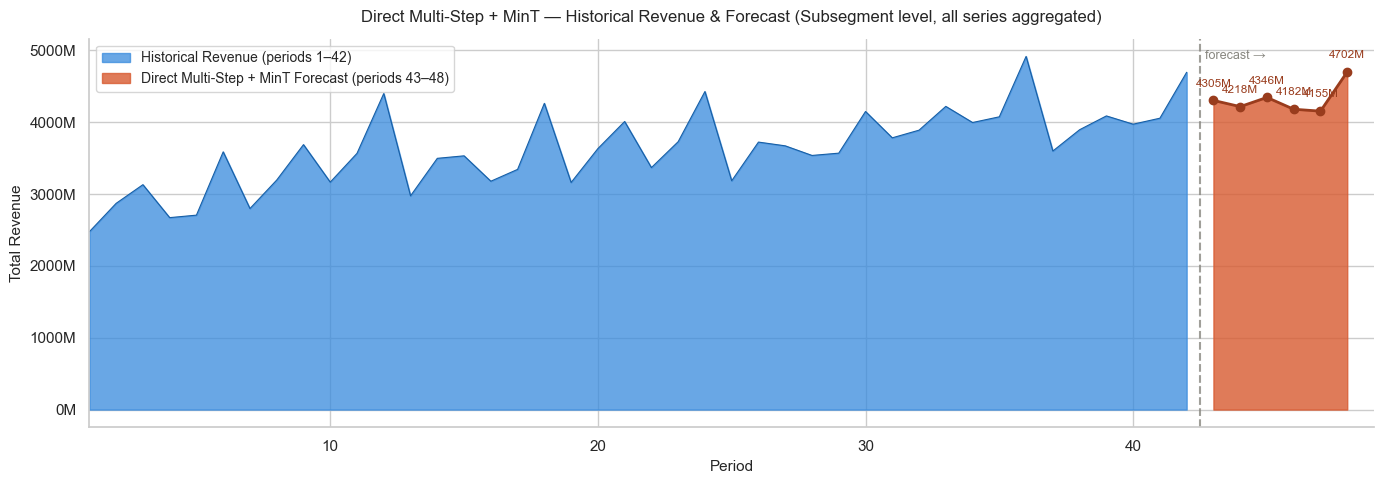

Plot saved to: forecast_plot_direct_multi-step_+_mint.png


In [22]:
from pathlib import Path

plot_path = plot_forecast_comparison(
    train_df=train_full,
    submission_df=test_export,
    period_col="Anon Period",
    target_col="Revenue cons. (anon)",
    best_model_name="Direct Multi-Step + MinT",
    output_dir=Path("."),
    forecast_col="Revenue cons. (anon)"
)

print(f"Plot saved to: {plot_path}")